In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

<h2 style="color: #9ACC2F;"> Objective: A telecom-company seek to drive strategies to increase customer upgrates to higher bundles </h2>

<h2 style="color: #FFFFFF;">About Dataset</h2>

> dataset of 70000 records for the past three months (m1, m2, m3) grouped by customerID and RatePlan (current) regarding overall usage (voice & data), total_revenue, flag if current rateplan upgraded to Bundle2000 or not <br>
> Need to build a predective model to identify customers who are likely to benefit from upgrading to a more expensive bundle. <br>
> Event Rate: Upgrading to a higher bundle (currently 1%) <br>


**Columns Description**
* Subscription_id        ------> Customer ID with detailed usage and revenue and rateplan 
* og_usage_m3            ------> outgoing voice minutes (m3)
* og_usage_m2            ------> outgoing voice minutes (m2)
* og_usage_m1            ------> outgoing voice minutes (m1)
* data_usage_m3          ------> data usage in MBs (m3)
* data_usage_m2          ------> data usage in MBs (m2)
* data_usage_m1          ------> data usage in MBs (m1)
* rev_m3                 ------> Total Revenue per customer (m3)
* rev_m2                 ------> Total Revenue per customer (m2)
* rev_m1                 ------> Total Revenue per customer (m1)
* Rate_Plan_Desc         ------> Previous rate plan description
* Most_Used_Region       ------> region where customer use their bundle
* aon                    ------> Age_on_Network_Days
* post_migration_plan    ------> Upgrading event flag (migrated to Bundle2000 or not)

## **loading dataset**

In [3]:
df = pd.read_csv(r'E:\Data Analysis Diploma (4 MONTHS)\Lecture28\KPIs_Data.txt', delimiter='\t')
df

,Subscription_Id,og_usage_m3,og_usage_m2,og_usage_m1,data_usage_m3,data_usage_m2,data_usage_m1,rev_m3,rev_m2,rev_m1,Rate_Plan_Desc,Most_Used_Region,aon,post_migration_plan
0,127122557,3422,3862,3679,4578,8225,6200,61.31,318.42,547.56,BundleChild Voice,G.Cairo,2942,Bundle 2000
1,157038198,1257,755,953,33,14,10,9.61,10.44,11.27,BundleChild Voice,?,112,Bundle 2000
2,192116383,612,1153,617,4514,1081,5468,739.55,863.5,2280.21,Bundle1150,G.Cairo,?,Bundle 2000
3,116872408,3882,1796,2270,42645,20197,23004,378.83,1010.38,1552.94,Bundle230,G.Cairo,3225,Bundle 2000
4,86447560,347,380,317,1434,1841,960,26.95,238.17,634.22,Bundle230,G.Cairo,3592,Bundle 2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,180264709,781,1225,1544,2286,8259,4454,0.83,1.66,2.49,BundleChild Voice,G.Cairo,1029,?
69996,178092376,14,12,1,263,0,0,0.83,1.66,2.49,BundleChild Voice,G.Cairo,1132,?
69997,194038849,792,1054,373,32115,11292,1297,659.63,1099.15,1579.9,Bundle230,Upper,337,?
69998,183416262,0,0,0,0,19,0,0.83,1.66,2.49,BundleChild Voice,G.Cairo,860,?


## **Exploring columns**

In [4]:
'''Statistical summary (descriptive statistics for dataframe) '''
df.describe(include='all')

,Subscription_Id,og_usage_m3,og_usage_m2,og_usage_m1,data_usage_m3,data_usage_m2,data_usage_m1,rev_m3,rev_m2,rev_m1,Rate_Plan_Desc,Most_Used_Region,aon,post_migration_plan
count,7.000000e+04,70000,70000,70000,70000,70000,70000,70000,70000,70000,70000,70000,70000,70000
unique,NaN,4364,4404,4245,27433,27315,26381,13920,22051,27733,6,6,6023,2
top,NaN,0,0,0,0,0,0,0.83,1.66,2.49,BundleChild Voice,G.Cairo,?,?
freq,NaN,6520,6795,7801,8516,8811,9854,18480,16004,14488,32043,42451,479,69296
mean,1.410090e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,6.006165e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,8.491000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.014815e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.668224e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.879417e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
'''Brief about structure, memory usage and datatypes '''
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Subscription_Id      70000 non-null  int64 
 1   og_usage_m3          70000 non-null  object
 2   og_usage_m2          70000 non-null  object
 3   og_usage_m1          70000 non-null  object
 4   data_usage_m3        70000 non-null  object
 5   data_usage_m2        70000 non-null  object
 6   data_usage_m1        70000 non-null  object
 7   rev_m3               70000 non-null  object
 8   rev_m2               70000 non-null  object
 9   rev_m1               70000 non-null  object
 10  Rate_Plan_Desc       70000 non-null  object
 11  Most_Used_Region     70000 non-null  object
 12  aon                  70000 non-null  object
 13  post_migration_plan  70000 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.5+ MB


In [6]:
df['Subscription_Id'].nunique() 
df['Subscription_Id'].isna().sum()
##### rename column to "customer_id"


'''Actions'''
# df.rename(columns={'Subscription_Id': 'customer_id'}, inplace=True)

'Actions'

In [7]:
df['Rate_Plan_Desc'].nunique()
df['Rate_Plan_Desc'].unique()
df[['Rate_Plan_Desc']].drop_duplicates()
##### rename column to "prev_rate_plan"



'''Actions'''
# df.rename(columns={'Rate_Plan_Desc': 'prev_rate_plan'}, inplace=True)

'Actions'

In [8]:
df.query("Most_Used_Region == '?'") #count: 9058
''' 
'G.Cairo': 'Greater Cairo',
'G.Alex': 'Greater Alexandria',
'Upper': 'Upper Egypt',
'Delta': 'Nile Delta',
'Canal': 'Suez Canal Region'
'?': 'Unknown'
'''
df['Most_Used_Region'].unique()
#### rename column name to "Region Name"
#### map values to more clear values




'''Actions'''
# df.rename(columns={'Most_Used_Region': 'region_name'}, inplace=True)
# region_mapper={
#         'G.Cairo': 'Greater Cairo',
#         'G.Alex': 'Greater Alexandria',
#         'Upper': 'Upper Egypt',
#         'Delta': 'Nile Delta',
#         'Canal': 'Suez Canal Region',
#         '?': 'Unknown'
# }



# df['region_name'].replace(region_mapper, inplace=True)
# df['region_name'].value_counts()

'Actions'

In [9]:
df['aon'].isna().sum()
df['aon'].unique()
(df['aon'] == "?").sum() #count: 479


#### rename column to "Age_on_network"
#### replace value "?" to something suitable 



'''Actions'''
# df.rename(columns={'aon':'age_on_network(days)'}, inplace=True)
# aon_median_value = df.loc[df['age_on_network(days)'] != "?", 'age_on_network(days)'].astype('int64').median()
# df.loc[df['age_on_network(days)'] == "?", 'age_on_network(days)'] = int(aon_median_value)
# (df['age_on_network(days)'] == "?").sum()

'Actions'

In [10]:
df.loc[df['post_migration_plan'] == "?", 'post_migration_plan'].count() #count: 69296
df['post_migration_plan'].unique()


#rename column to "Upgrading_to_Bundle2000_flag"
#change values to "yes/no"


'''Actions'''
# df.rename(columns={'post_migration_plan':'Upgrading_to_Bundle2000_flag'}, inplace=True)
# flag_mapper = {'Bundle 2000':'yes', '?':'no'}
# df['Upgrading_to_Bundle2000_flag'].replace(flag_mapper, inplace=True)
# df['Upgrading_to_Bundle2000_flag'].value_counts() OR df.query("Upgrading_to_Bundle2000_flag == '?'")

'Actions'

In [11]:
'''All Actions'''

df.rename(columns={'Subscription_Id': 'customer_id', 'Rate_Plan_Desc': 'prev_rate_plan', 'Most_Used_Region': 'region_name', 'aon':'age_on_network(days)', 'post_migration_plan':'bundle_upgrading_flag'}, inplace=True)



#region_name column
region_mapper={
        'G.Cairo': 'Greater Cairo',
        'G.Alex': 'Greater Alexandria',
        'Upper': 'Upper Egypt',
        'Delta': 'Nile Delta',
        'Canal': 'Suez Canal Region',
        '?': 'Unknown'
}
df['region_name'] = df['region_name'].replace(region_mapper)
print(df['region_name'].value_counts())



#age_on_network column
aon_median_value = df.loc[df['age_on_network(days)'] != "?", 'age_on_network(days)'].astype('int64').median()
df.loc[df['age_on_network(days)'] == "?", 'age_on_network(days)'] = int(aon_median_value) 
print((df['age_on_network(days)'] == "?").sum())



#2000Bundle flag column
flag_mapper = {'Bundle 2000':'yes', '?':'no'}
df['bundle_upgrading_flag'] = df['bundle_upgrading_flag'].replace(flag_mapper)
print(df['bundle_upgrading_flag'].value_counts())
df.query("bundle_upgrading_flag == '?'")


region_name
Greater Cairo         42451
Unknown                9058
Upper Egypt            5963
Nile Delta             5633
Greater Alexandria     5200
Suez Canal Region      1695
Name: count, dtype: int64
0
bundle_upgrading_flag
no     69296
yes      704
Name: count, dtype: int64


,customer_id,og_usage_m3,og_usage_m2,og_usage_m1,data_usage_m3,data_usage_m2,data_usage_m1,rev_m3,rev_m2,rev_m1,prev_rate_plan,region_name,age_on_network(days),bundle_upgrading_flag


In [12]:
'''Actions'''
df.query(" `age_on_network(days)` == '?'")
df.query(" `age_on_network(days)` == '?'")
# df['aon'] = (df['aon']/30).astype('int')
df['age_on_network(months)'] = (df['age_on_network(days)'].astype('int64') / (365.25/12)).round(2)
df = df.reindex(columns=['customer_id', 
                    'og_usage_m3', 
                    'og_usage_m2', 
                    'og_usage_m1',
                    'data_usage_m3',
                    'data_usage_m2',
                    'data_usage_m1',	
                    'rev_m3',
                    'rev_m2',
                    'rev_m1',
                    'prev_rate_plan',
                    'region_name',
                    'age_on_network(days)',
                    'age_on_network(months)',
                    'bundle_upgrading_flag'
                    ]
            )
df

,customer_id,og_usage_m3,og_usage_m2,og_usage_m1,data_usage_m3,data_usage_m2,data_usage_m1,rev_m3,rev_m2,rev_m1,prev_rate_plan,region_name,age_on_network(days),age_on_network(months),bundle_upgrading_flag
0,127122557,3422,3862,3679,4578,8225,6200,61.31,318.42,547.56,BundleChild Voice,Greater Cairo,2942,96.66,yes
1,157038198,1257,755,953,33,14,10,9.61,10.44,11.27,BundleChild Voice,Unknown,112,3.68,yes
2,192116383,612,1153,617,4514,1081,5468,739.55,863.5,2280.21,Bundle1150,Greater Cairo,1680,55.20,yes
3,116872408,3882,1796,2270,42645,20197,23004,378.83,1010.38,1552.94,Bundle230,Greater Cairo,3225,105.95,yes
4,86447560,347,380,317,1434,1841,960,26.95,238.17,634.22,Bundle230,Greater Cairo,3592,118.01,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,180264709,781,1225,1544,2286,8259,4454,0.83,1.66,2.49,BundleChild Voice,Greater Cairo,1029,33.81,no
69996,178092376,14,12,1,263,0,0,0.83,1.66,2.49,BundleChild Voice,Greater Cairo,1132,37.19,no
69997,194038849,792,1054,373,32115,11292,1297,659.63,1099.15,1579.9,Bundle230,Upper Egypt,337,11.07,no
69998,183416262,0,0,0,0,19,0,0.83,1.66,2.49,BundleChild Voice,Greater Cairo,860,28.25,no


## **Handling null values in numeric values &&& Datatypes**

og_usage_m3, og_usage_m2, og_usage_m1, data_usage_m3, data_usage_m2, data_usage_m1, rev_m3, rev_m2,	rev_m1

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             70000 non-null  int64  
 1   og_usage_m3             70000 non-null  object 
 2   og_usage_m2             70000 non-null  object 
 3   og_usage_m1             70000 non-null  object 
 4   data_usage_m3           70000 non-null  object 
 5   data_usage_m2           70000 non-null  object 
 6   data_usage_m1           70000 non-null  object 
 7   rev_m3                  70000 non-null  object 
 8   rev_m2                  70000 non-null  object 
 9   rev_m1                  70000 non-null  object 
 10  prev_rate_plan          70000 non-null  object 
 11  region_name             70000 non-null  object 
 12  age_on_network(days)    70000 non-null  object 
 13  age_on_network(months)  70000 non-null  float64
 14  bundle_upgrading_flag   70000 non-null

In [14]:
# df.query("og_usage_m3 == '?'") #3710 
# df.query("og_usage_m2 == '?'") #3710 
# df.query("og_usage_m1 == '?'") #3710 
# df.query("data_usage_m3 == '?'") #3710 
# df.query("data_usage_m2 == '?'") #3710 
# df.query("data_usage_m1 == '?'") #3710



# df.query("rev_m3 == '?'") #1296
# df.query("rev_m2 == '?'") #483
# df.query("rev_m1 == '?'") #443

In [15]:
df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")['region_name'].value_counts() #3710

region_name
Unknown               3636
Greater Cairo           43
Upper Egypt             15
Nile Delta               7
Greater Alexandria       7
Suez Canal Region        2
Name: count, dtype: int64

In [16]:
df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")['prev_rate_plan'].value_counts() #3710

prev_rate_plan
Bundle230            1640
BundleChild Voice    1227
Bundle450             363
Bundle1150            303
Bundle690             130
Bundle2300             47
Name: count, dtype: int64

In [17]:
df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")['bundle_upgrading_flag'].value_counts() #3710

bundle_upgrading_flag
no     3692
yes      18
Name: count, dtype: int64

In [18]:
df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")['age_on_network(months)'].value_counts().head() #3710
#high retention

age_on_network(months)
55.20    262
8.05      15
8.74      13
9.59      12
5.59      12
Name: count, dtype: int64

In [19]:
df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")[['rev_m3']].query("rev_m3 != '?'").astype('float64').sum() #rev_m3: $321,084.0


df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")[['rev_m2']].query("rev_m2 != '?'").astype('float64').sum() #rev_m2: $675,812.05



df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")[['rev_m1']].query("rev_m1 != '?'").astype('float64').sum() #rev_m1: $1,033,216.53


rev_m1    1033216.53
dtype: float64

In [20]:
df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")[['rev_m3']].query("rev_m3 == '?'").count() #count: 431 

df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")[['rev_m2']].query("rev_m2 == '?'").count()  #count: 374


df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")[['rev_m1']].query("rev_m1 == '?'").count() #count: 358

rev_m1    358
dtype: int64

In [21]:
df[['rev_m3']].query("rev_m3 != '?'").astype('float64').sum()  # total rev_m3: $20,285,672.3
df[['rev_m2']].query("rev_m2 != '?'").astype('float64').sum()  # total rev_m2: $42,008,474.3
df[['rev_m1']].query("rev_m1 != '?'").astype('float64').sum()  # total rev_m1: $65,374,653.69

#revenue for missing usage / total revenue %
((df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")[['rev_m3']].query("rev_m3 != '?'").astype('float64').sum()) / (df[['rev_m3']].query("rev_m3 != '?'").astype('float64').sum()) )*100  #1.58%

((df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")[['rev_m2']].query("rev_m2 != '?'").astype('float64').sum()) / (df[['rev_m2']].query("rev_m2 != '?'").astype('float64').sum())) *100 #1.6%


((df.query("og_usage_m3 == '?' and og_usage_m2 == '?' and og_usage_m1 == '?' " \
        "and data_usage_m3 == '?' and data_usage_m2 == '?' and data_usage_m1 == '?'")[['rev_m1']].query("rev_m1 != '?'").astype('float64').sum()) / (df[['rev_m1']].query("rev_m1 != '?'").astype('float64').sum())) *100 #1.58%

rev_m1    1.580454
dtype: float64

#### Usage Data Null Handling 💡

The handling for missing usage data (minutes or MBs) will be the same across all usage metrics. The consistent structure in the count of null values suggests these are **structural nulls** (3,710 records affected across all usage columns). This systematic failure to record usage is likely due to a technical issue in one of the systems of the business flow, a specific rate plan setup, or a data collection/processing issue.

**Best Practice:**
<h4 style="color:#27F5B7;">Impute with zero AND create a missingness flag.</h4>

In [22]:
df['usage_missing_data_flag'] = df['data_usage_m1'].apply(lambda x:1 if x=='?' else 0)  #applied on 3710
df['usage_missing_data_flag'].sum()


for col in [x for x in df.columns if 'usage' in x]:
    df.loc[df[col] == '?', col] = 0


(df['data_usage_m2'] == "?").sum()
df[['usage_missing_data_flag']].value_counts()

# for col in []

usage_missing_data_flag
0                          66290
1                           3710
Name: count, dtype: int64

#### Revenue Data Null Handling 💰 

The handling of missing data in revenue columns is **inconsistent in the null counts** across months (e.g., rev_m3 vs. rev_m1) and affects a very small percentage of the total revenue data. Since revenue is an additive financial metric, imputing anything other than zero would introduce phantom earnings.

**Best Practice:**
<h4 style="color:#27F5B7;">Impute with zero only.</h4>

In [23]:
for col in [x for x in df.columns if 'rev_m' in x]:
    # print(col)
    df.loc[df[col] == "?", col] = 0 



(df['rev_m1'] == "?").sum()

np.int64(0)

#### datatypes handling

In [24]:
df['og_usage_m3'] = df['og_usage_m3'].astype('int64')
df['og_usage_m2'] = df['og_usage_m2'].astype('int64')
df['og_usage_m1'] = df['og_usage_m1'].astype('int64')
df['data_usage_m3'] = df['data_usage_m3'].astype('int64')
df['data_usage_m2'] = df['data_usage_m2'].astype('int64')
df['data_usage_m1'] =df['data_usage_m1'].astype('int64')
df['rev_m3'] = df['data_usage_m3'].astype('int64')
df['rev_m2'] = df['data_usage_m2'].astype('int64')
df['rev_m1'] =df['data_usage_m1'].astype('int64')

In [25]:
df.drop('age_on_network(days)', axis=1, inplace=True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              70000 non-null  int64  
 1   og_usage_m3              70000 non-null  int64  
 2   og_usage_m2              70000 non-null  int64  
 3   og_usage_m1              70000 non-null  int64  
 4   data_usage_m3            70000 non-null  int64  
 5   data_usage_m2            70000 non-null  int64  
 6   data_usage_m1            70000 non-null  int64  
 7   rev_m3                   70000 non-null  int64  
 8   rev_m2                   70000 non-null  int64  
 9   rev_m1                   70000 non-null  int64  
 10  prev_rate_plan           70000 non-null  object 
 11  region_name              70000 non-null  object 
 12  age_on_network(months)   70000 non-null  float64
 13  bundle_upgrading_flag    70000 non-null  object 
 14  usage_missing_data_fla

## **Explore by charts** 

#### **Comparison Charts: Rate Plan Performance (Your List 1 & 2) 📊**

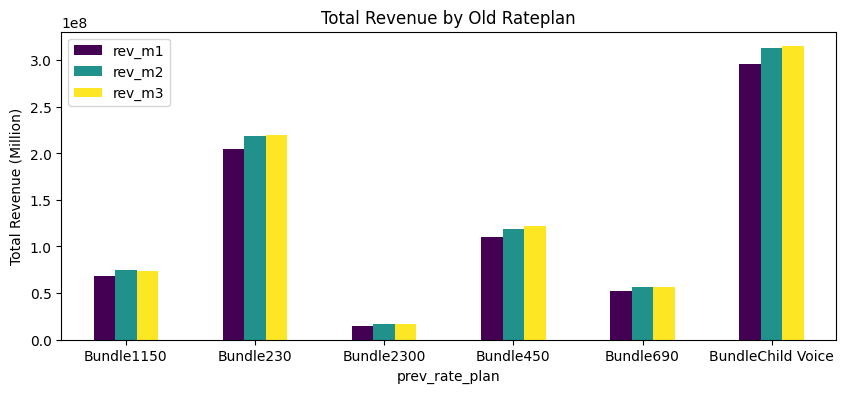

In [27]:
# Revenue by All Previous Rate Plans
df.groupby('prev_rate_plan')[['rev_m3', 'rev_m2', 'rev_m1']].agg({'rev_m1':'sum', 'rev_m2':'sum', 'rev_m3':'sum'}).plot(kind='bar', colormap='viridis', figsize=(10,4), title='Total Revenue by Old Rateplan')
plt.xticks(rotation=0)
plt.ylabel("Total Revenue (Million)")
plt.show()

******************* As shown Rateplan "BundleChild Voice" Rateplan customers has the highest chance to upgrade their rateplan

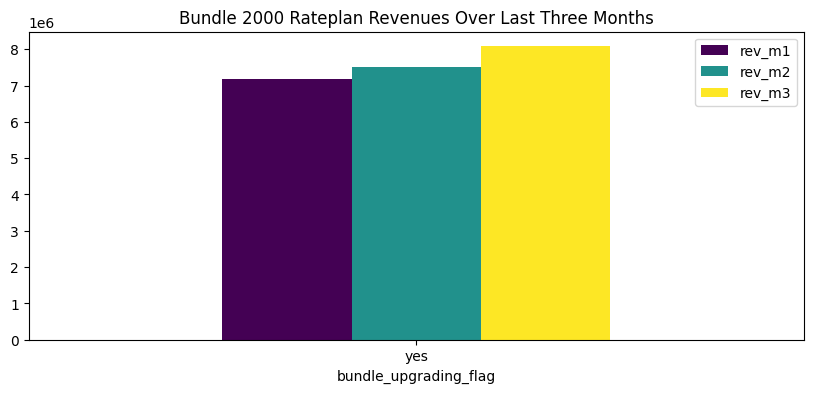

In [ ]:
# Upgraded Plan Revenue
df.query("bundle_upgrading_flag == 'yes'").groupby('bundle_upgrading_flag')[['rev_m3', 'rev_m2', 'rev_m1']].agg({'rev_m1':'sum', 'rev_m2':'sum', 'rev_m3':'sum'}).plot(kind='bar', figsize=(10, 4), colormap='viridis', title='Bundle 2000 Rateplan Revenues Over Last Three Months')

plt.xticks(rotation=0)
plt.show()

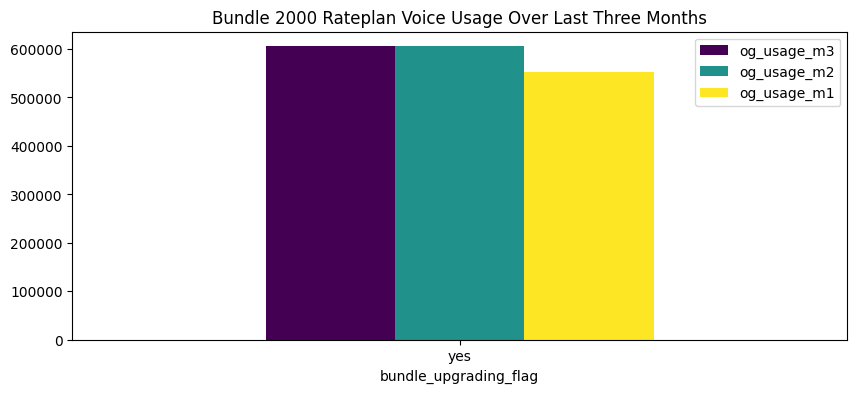

In [ ]:
# Upgraded Plan Usage (Calls)
df.query("bundle_upgrading_flag == 'yes'").groupby('bundle_upgrading_flag')[['og_usage_m3', 'og_usage_m2', 'og_usage_m1']].agg({'og_usage_m3':'sum', 'og_usage_m2':'sum', 'og_usage_m1':'sum'}).plot(kind='bar',  figsize=(10, 4), colormap='viridis', title='Bundle 2000 Rateplan Voice Usage Over Last Three Months')

plt.xticks(rotation=0)
plt.show()

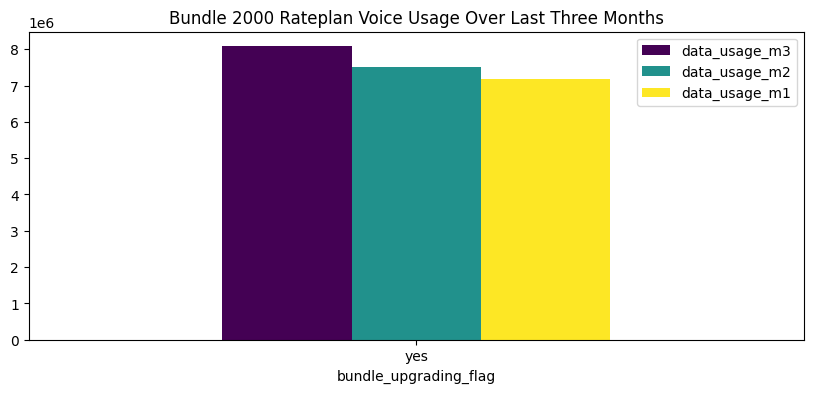

In [ ]:
# Upgraded Plan Usage (Data)
df.query("bundle_upgrading_flag == 'yes'").groupby('bundle_upgrading_flag')[['data_usage_m3', 'data_usage_m2', 'data_usage_m1']].agg({'data_usage_m3':'sum', 'data_usage_m2':'sum', 'data_usage_m1':'sum'}).plot(kind='bar',  figsize=(10, 4), colormap='viridis', title='Bundle 2000 Rateplan Data Usage Over Last Three Months')

plt.xticks(rotation=0)
plt.show()

*************** For upgraded rateplan usage and revenue over last three months. Revenue slightly descreases by time and usage as well. We have to check characteristics of the rateplan and get our customer satisfaction

#### **Distribution Chart: Age on Network && Revenue Distribution for Upgrader and Non-Upgrader ⏳** </br

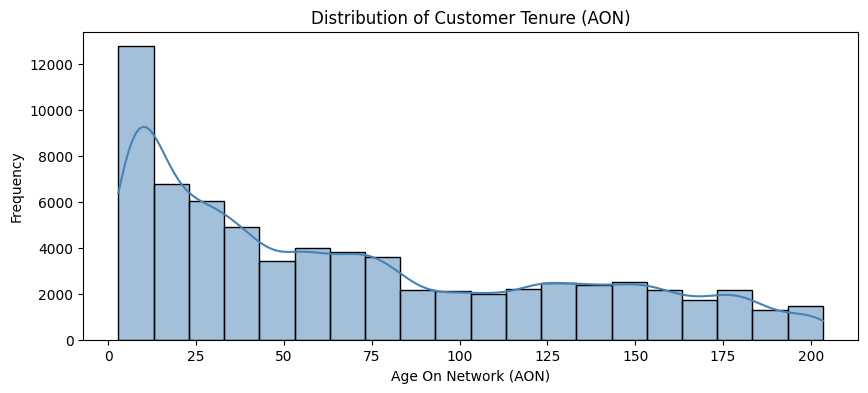

In [69]:
'''Age_on_Network_Days'''
# df['aon(month)'].plot(kind='hist', bins=20)

# df['age_on_network(months)'].plot(kind='hist', bins=20, figsize=(12,4), title="Distribution of Customer AON")
# fig, ax = plt.subplots(figsize=(12, 4))
plt.figure(figsize=(10, 4))
sns.histplot(df['age_on_network(months)'], kde=True, bins=20, color='steelblue')

plt.xlabel("Age On Network (AON)")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Tenure (AON)")
plt.show()

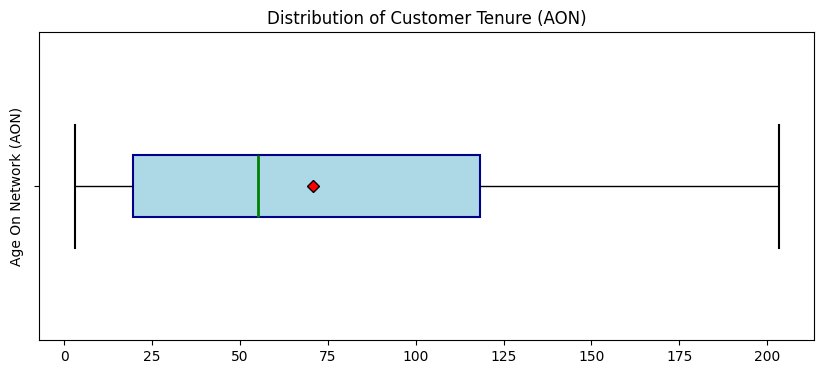

In [119]:
# The Boxplot is great for quickly identifying the median tenure and any potential outliers (very old customers).
# df['age_on_network(months)'].plot(kind='box', figsize=(10,6), )

plt.figure(figsize=(10,4))
sns.boxplot(x=df['age_on_network(months)'], 
                showmeans=True, 
                whis=1.5, 
                boxprops= {'facecolor':'lightblue', 'edgecolor':'darkblue', 'linewidth':1.5}, # Color and width of the box
                medianprops={'color': 'green', 'linewidth': 2},  # Color of the median line
                whiskerprops = {'color':'black', 'linewidth':1},
                capprops= {'linewidth':1.5, 'color':'black', 'linestyle':'-'},  
                meanprops={'marker': 'D', 'markeredgecolor': 'black', 'markerfacecolor': 'red'}, # Color of the mean marker
                widths=0.2 #width of the box 
                )

plt.ylabel("Age On Network (AON)")
plt.xlabel('')
plt.title("Distribution of Customer Tenure (AON)")
plt.show()


************************ Histogram Interpretation
dataset gives a right-skewed (+ve skewed) histogram with highest frequency concentrated on the left between (0-25) AON (mnonths). And, the distribution is trails off to the right. This means that the majority of our customers have low age on the network (steady customers or new customers). Low loyality or Low retention or small tenure. 

************************ boxplot distribution 
since mean>median, this is a skewness insight (right-skewed). More than half of customer base has low tenure. The median tenure is relatively short at 55 months, suggesting that customer retention beyond the five-year mark is where the customer base thins out.

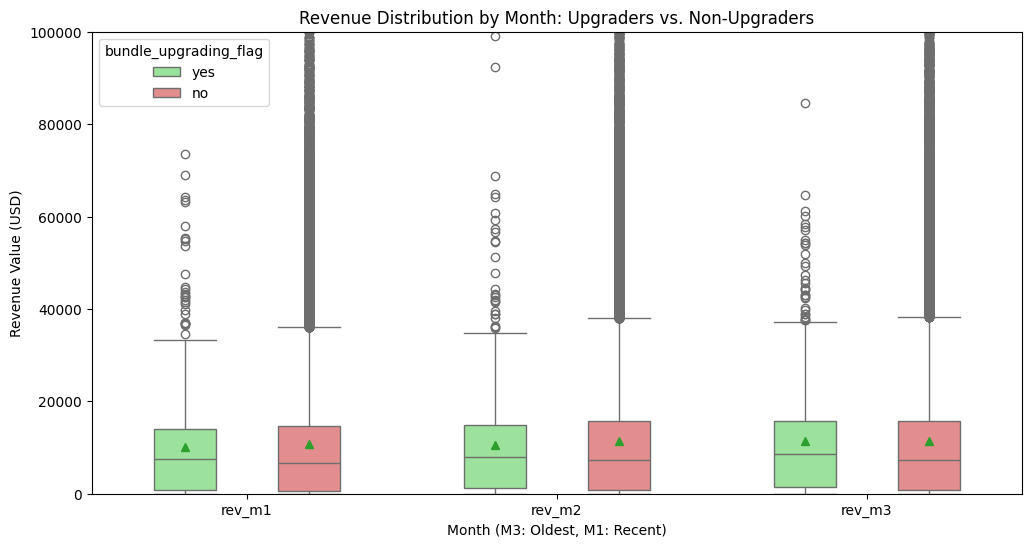

In [160]:
unpivoted_revenue_by_upgradingFlag = pd.melt(
    df,
    id_vars=['bundle_upgrading_flag'],         # Keep this column as the ID
    value_vars=['rev_m1', 'rev_m2', 'rev_m3'],                   # These columns will be unpivoted
    var_name='Month',                          # Name of the new column storing 'rev_m1', 'rev_m2', etc.
    value_name='Revenue_Value'                 # Name of the new column storing the actual revenue figures
)



plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Month', 
    y='Revenue_Value',
    hue= 'bundle_upgrading_flag',
    data=unpivoted_revenue_by_upgradingFlag,
    palette=[ 'lightgreen', 'lightcoral',],
    showmeans=True, 
    # whis=1.5, 
    widths=0.2 #width of the box 
                
)

plt.ylim(0, 100000) # Zoom in to see the box/whiskers clearly
plt.title('Revenue Distribution by Month: Upgraders vs. Non-Upgraders')
plt.xlabel('Month (M3: Oldest, M1: Recent)')
plt.ylabel('Revenue Value (USD)')
plt.show()

****************************** Differences appears in outliers and whisker
1. Over M3...M1, whisker of Non-Upgraders higher than Upgrader customers --> Higher variability for non-upgraders' revenues. This will make non-upgraders revenues less predectable compared to upgraders as non-upgraders almost cover all revenue ranges.
2. Over M3...M1, Revenue Outliers for Non-Upgraders more intense than Upgraders. --> High-retention (high-value) customers are non-upgraders. Upgrade bundle (Bundle2000) fail to reach high-value customers/segment.


#### **Comparision Charts: Customers By Region**

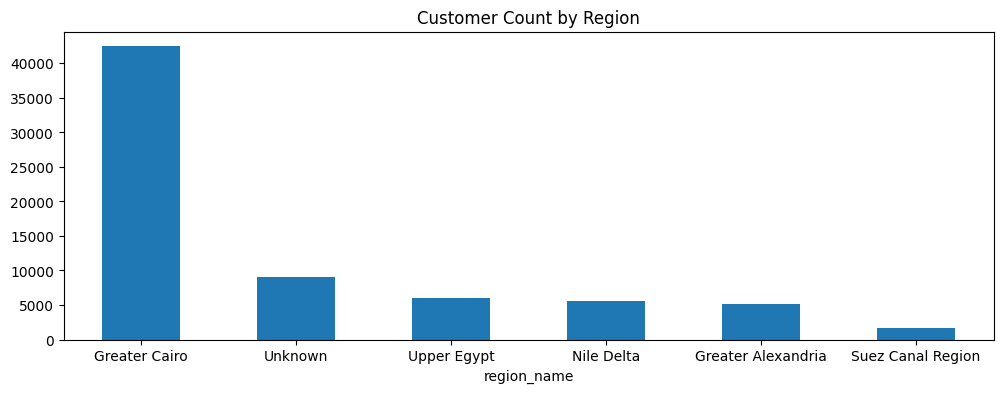

In [ ]:
# df.loc[:,['region_name', 'customer_id']].set_index('region_name').groupby('region_name').agg({'customer_id': 'count'}).plot(kind='bar', legend=False, figsize=(10,6), title="Top 10 Household sales", ylabel="Total Sales", )


df['region_name'].value_counts().plot(kind='bar', title='Customer Count by Region', figsize=(12,4))
plt.xticks(rotation=0)
plt.show()

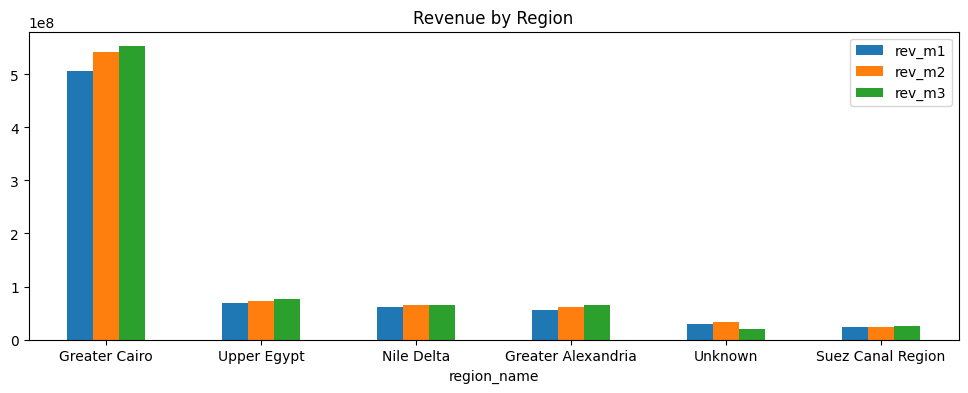

In [138]:
df.groupby('region_name')[['rev_m1', 'rev_m2', 'rev_m3']].agg({'rev_m1':'sum','rev_m2':'sum', 'rev_m3':'sum'}).sort_values(by=['rev_m1', 'rev_m2', 'rev_m3'], ascending=False).plot(kind='bar', title='Revenue by Region', figsize=(12,4))


plt.xticks(rotation=0)
plt.show()

********************** As shown, Cairo has the highest customer-base and financial revenue 